# Sistema y simulación

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
from numba import njit, prange
import seaborn as sns

def construir_matriz_ISLM(N, C, sigma, mu_K=0, sigma_K=1):
    """
    Construye la matriz de interacción A siguiendo el ensamble balanceado
    del artículo de Calvo et al. (2026).
    """
    # 1. Generar las capacidades de carga K_i (Log-normal)
    K = np.random.lognormal(mean=mu_K, sigma=sigma_K, size=N)
    
    # 2. Matriz de conectividad B (Bernoulli con probabilidad C)
    B = (np.random.rand(N, N) < C).astype(float)
    np.fill_diagonal(B, 0) # Sin auto-interacciones en la red aleatoria
    
    # 3. Matriz de pesos aleatorios Z con varianza 1/N
    Z = np.random.normal(0, 1.0 / np.sqrt(N), size=(N, N))
    np.fill_diagonal(Z, 0)
    
    # 4. Balancear las filas para obtener G (suma por fila = 0)
    G = np.zeros((N, N))
    for i in range(N):
        indices_activos = np.where(B[i, :] == 1)[0]
        if len(indices_activos) > 0:
            z_activos = Z[i, indices_activos]
            # Restamos la media de los enlaces activos de esa fila
            G[i, indices_activos] = z_activos - np.mean(z_activos)
            
    # 5. Ensamble final: A_ij = sigma * G_ij / K_j  (para i != j)
    # Usamos broadcasting de numpy para dividir eficientemente cada columna j por K[j]
    A = sigma * (G / K[np.newaxis, :])
    
    # Forzamos la diagonal D_ii = -1 / K_i
    np.fill_diagonal(A, -1.0 / K)
    
    return A, K

@njit(fastmath=True, parallel=True)
def getMaxRealPart(N, C_range, n_average, sigma_n_range, sigma_ln_range):
    # Dimensiones de los rangos
    n_connect = C_range.shape[0]
    n_sn = sigma_n_range.shape[0]
    n_sln = sigma_ln_range.shape[0]
    
    # El resultado final es un array 3D: (conectividad, sigma_n, sigma_ln)
    list_eigvals_avg = np.zeros((n_connect, n_sn, n_sln), dtype=np.float64)
    
    # Pre-calculamos N_c para evitar operaciones repetitivas
    N_c_list = (N * N * C_range).astype(np.int64)

    # Bucle 1: Paralelizamos SOLO el nivel más externo
    for i in prange(n_connect):
        N_c = N_c_list[i]
        
        # Bucles internos usan range normal
        for j in range(n_sn):
            sn = sigma_n_range[j]
            
            for k in range(n_sln):
                sln = sigma_ln_range[k]
                sum_max_re = 0.0
                
                # Bucle de Monte Carlo
                for t in range(n_average):
                    
                    # 1. Poblamos la matriz A usando Muestreo por Rechazo
                    A_flat = np.zeros(N * N, dtype=np.float64)
                    is_filled = np.zeros(N * N, dtype=np.bool_) # Control de posiciones
                    
                    if N_c <= (N * N) // 2:
                        # Opción A: Baja densidad. Buscamos casillas vacías y las llenamos
                        added = 0
                        while added < N_c:
                            idx = np.random.randint(0, N * N)
                            if not is_filled[idx]:
                                A_flat[idx] = np.random.normal(0.0, sn)
                                is_filled[idx] = True
                                added += 1
                    else:
                        # Opción B: Alta densidad. Llenamos TODO y luego vaciamos huecos
                        for idx in range(N * N):
                            A_flat[idx] = np.random.normal(0.0, sn)
                            is_filled[idx] = True
                            
                        to_remove = (N * N) - N_c
                        removed = 0
                        while removed < to_remove:
                            idx = np.random.randint(0, N * N)
                            if is_filled[idx]:
                                A_flat[idx] = 0.0
                                is_filled[idx] = False
                                removed += 1
                                
                    A = A_flat.reshape((N, N))

                    # 2. Generamos K y ajustamos diagonal de A
                    K = np.random.lognormal(0.0, sln, N)
                    for diag_idx in range(N):
                        A[diag_idx, diag_idx] = -1.0 / K[diag_idx]

                    # 3. Calculamos el Jacobiano J
                    J = np.zeros((N, N), dtype=np.float64)
                    for r in range(N):
                        row_sum = 0.0
                        for c in range(N):
                            val = A[r, c] * K[c]
                            J[r, c] = val
                            row_sum += val
                        # La diagonal de J es la suma de la fila de A_ij * K_j
                        J[r, r] = row_sum

                    # 4. Calculamos autovalores SIN forzar a complejo (más rápido)
                    vals = np.linalg.eigvals(J)
                    
                    # 5. Buscamos la parte real máxima
                    max_re = -np.inf 
                    for v in vals:
                        if v.real > max_re:
                            max_re = v.real
                    
                    sum_max_re += max_re
                
                # Guardamos el promedio
                list_eigvals_avg[i, j, k] = sum_max_re / n_average
                
    return list_eigvals_avg

@njit(fastmath=True)
def drift(x, tau, K):
    return x/tau * (1 - x/K)

@njit(fastmath=True)
def diffusion(x, tau, sigma, epsilon):
    return x * sigma/tau * epsilon

@njit(fastmath=True)
def time_series(x_0, steps, dt, params):
    tau, K, sigma = params
    x = np.zeros(steps)
    x[0] = x_0[0]
    epsilon = np.random.standard_normal(steps)

    for i in range(1, steps):
        # Primero calculamos el término predictor del algoritmo de Heun
        drift_predictor = drift(x[i-1], tau, K)
        diffusion_predictor = diffusion(x[i-1], tau, sigma, epsilon[i-1])
        x_pred = x[i-1] + dt * drift_predictor + np.sqrt(dt) * diffusion_predictor

        # Y ahora el corrector
        drift_corrector = drift(x_pred, tau, K)
        diffusion_corrector = diffusion(x_pred, tau, sigma, epsilon[i-1])

        # Y finalmente promediamos las dos
        x[i] = x[i-1] + dt * 0.5 * (drift_predictor + drift_corrector) + np.sqrt(dt) * 0.5 * (diffusion_predictor + diffusion_corrector)

    return x

@njit
def samples(x_0, steps, dt, params):
    tau, K, sigma = params
    N = np.shape(x_0)[0]
    x = x_0

    for i in range(1, steps):
        epsilon = np.random.standard_normal(N)
        # Primero calculamos el término predictor del algoritmo de Heun
        drift_predictor = drift(x, tau, K)
        diffusion_predictor = diffusion(x, tau, sigma, epsilon)
        x_pred = x + dt * drift_predictor + np.sqrt(dt) * diffusion_predictor

        # Y ahora el corrector
        drift_corrector = drift(x_pred, tau, K)
        diffusion_corrector = diffusion(x_pred, tau, sigma, epsilon)

        # Y finalmente promediamos las dos
        x += dt * 0.5 * (drift_predictor + drift_corrector) + np.sqrt(dt) * 0.5 * (diffusion_predictor + diffusion_corrector)


    return x

@njit(fastmath=True)
def interacting_time_series(x_0, sigma, tau, dt, A, steps):
    N_species = x_0.shape[0]
    int_time_series = np.zeros((steps, N_species))
    int_time_series[0] = x_0
    for t in range(1, steps):
        for i in range(N_species):
            interaction_term = 0
            for j in range(N_species):
                interaction_term += A[i, j] * int_time_series[t-1, j]

            x_i = int_time_series[t-1, i]
            drift = x_i / tau * (1 + interaction_term)
            diffusion = x_i * sigma * np.random.standard_normal()
            int_time_series[t, i] = x_i + dt * drift + np.sqrt(dt) * diffusion
    
    return int_time_series

@njit(fastmath=True)
def deterministic_interacting_time_series(x_0, tau, dt, A, steps):
    N_species = x_0.shape[0]
    int_time_series = np.zeros((steps, N_species))
    int_time_series[0] = x_0
    for t in range(1, steps):
        for i in range(N_species):
            interaction_term = 0
            for j in range(N_species):
                interaction_term += A[i, j] * int_time_series[t-1, j]

            int_time_series[t, i] = int_time_series[t-1, i] + dt * int_time_series[t-1, i] / tau * (1 + interaction_term)
    
    return int_time_series

@njit(fastmath=True)
def drift(x, tau, K):
    return x/tau * (1 - x/K)

@njit(fastmath=True)
def diffusion(x, tau, sigma, epsilon):
    return x * sigma/tau * epsilon

@njit(fastmath=True)
def third_law(x_0, steps, dt, params):
    tau, K_range, sigma = params
    N = np.shape(x_0)[0]
    x = x_0
    mean_abundance = np.zeros(N)
    avg_steps = int(0.7 * steps)

    for i in range(1, steps):
        epsilon = np.random.standard_normal(N)
        for j in range(N):

            x[j] += dt *drift(x[j], tau, K_range[j]) + np.sqrt(dt) * diffusion(x[j], tau, sigma, epsilon[i])
            if i > 0.3 * steps:
                mean_abundance[j] += x[j]

    mean_abundance = mean_abundance/avg_steps
    return mean_abundance

## Primera ley

mu:  1.0016758867498898
std:  0.353675693636812


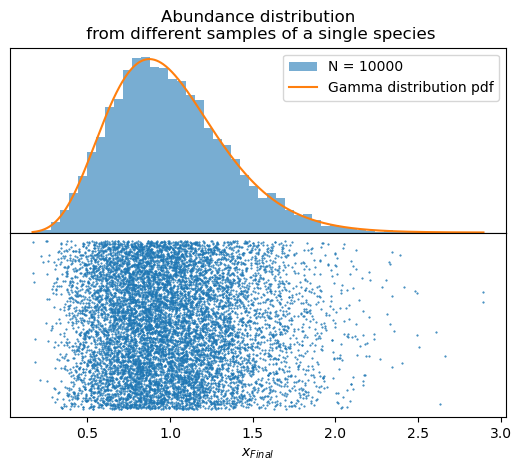

In [12]:
N = 10000
x_0 = np.ones(N)
steps = 10000
dt = 0.01
tau = 4
K = 1.0
sigma = 1
params = (tau, K, sigma)

x = samples(x_0, steps, dt, params)
fig, ax = plt.subplots(nrows=2, gridspec_kw = {'hspace':0})

ax[1].plot(x, np.arange(N), '.', markersize=1)
ax[1].set_xlabel(r"$x_{Final}$")
ax[1].set_yticks([])

mu = x.mean()
std = x.std()
print("mu: ", mu)
print("std: ", std)

_, bins, _ = ax[0].hist(x, bins=50, density=True, alpha=0.6, label=f"N = {N}")

x_range = np.linspace(bins.min(), bins.max(), 1000)

alpha = 2 * tau / sigma**2 
beta = 2 * tau / (K * sigma**2)
gamma = beta**alpha / sc.special.gamma(alpha) * x_range ** (alpha-1) * np.exp(-x_range * beta)
ax[0].plot(x_range, gamma, label="Gamma distribution pdf")
ax[0].set_yticks([])
ax[0].set_xticks([])
ax[0].legend()
ax[0].set_title("Abundance distribution\n from different samples of a single species")

plt.show()

## Segunda ley

Ejecutado paso  0 / 100
Ejecutado paso  10 / 100
Ejecutado paso  20 / 100
Ejecutado paso  30 / 100
Ejecutado paso  40 / 100
Ejecutado paso  50 / 100
Ejecutado paso  60 / 100
Ejecutado paso  70 / 100
Ejecutado paso  80 / 100
Ejecutado paso  90 / 100


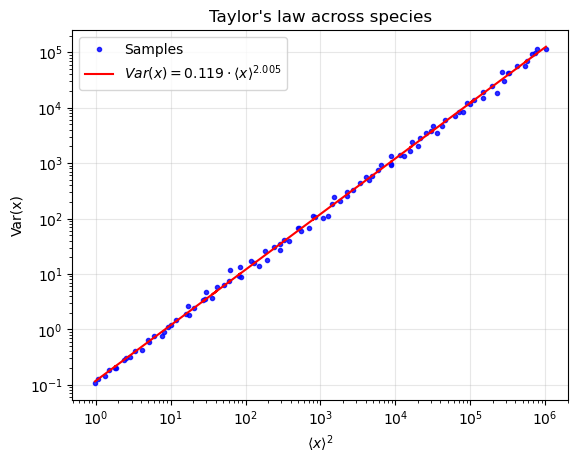

In [15]:
tau_range = 1 / np.linspace(2, 0.1, 100)
K_range = np.logspace(0, 3, 100)
sigma_range = np.sqrt(np.linspace(0, 3, 100))

N = 100
x_0 = np.ones(N)
steps = 5000
dt = 0.01
tau = 4
K = 1
sigma = 1

# Variando tau
variable = K_range
mean = np.zeros(len(variable))
var = np.zeros(len(variable))

for i in range(len(variable)):
    params = (tau, variable[i], sigma)
    x = samples(x_0, steps, dt, params)
    mean[i] = x.mean()
    var[i] = x.var()
    if 10 * i % len(variable) == 0:
        print("Ejecutado paso ", i, "/", len(variable))

# Sample plot
plt.loglog(mean**2, var, 'b.', alpha=0.8, label="Samples")
plt.xlabel(r"$\langle x \rangle^2$")
plt.ylabel("Var(x)")
plt.grid(True, alpha=0.3)

# Curve fit
def f(x, a, b):
    return b * x + a
log_mean = np.log(mean**2)
log_var = np.log(var)
popt, pcov = sc.optimize.curve_fit(f, log_mean, log_var)

y_pred = np.exp(popt[0]) * mean**(2 * popt[1])
plt.loglog(mean**2, y_pred, 'r', label=rf"$Var(x) = {np.exp(popt[0]):.3f} \cdot \langle x\rangle^{{{2 * popt[1]:.3f}}}$")
plt.title("Taylor's law across species")
plt.legend()
plt.show()


## Tercera ley

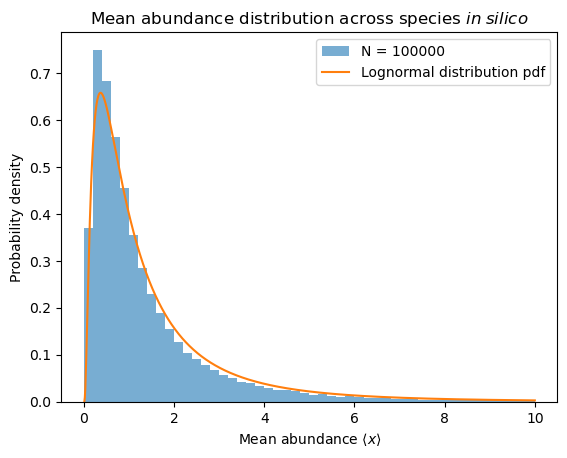

In [27]:
N = 100000
K_range = np.random.lognormal(mean=0, sigma=1, size=N)
x_0 = np.ones(N)
steps = 3000
dt = 0.1
tau = 4
sigma = 1

x_mean = third_law(x_0, steps, dt, (tau, K_range, sigma))

_, bins, _  = plt.hist(x_mean, bins=50, density=True, alpha=0.6, label=f"N = {N}", range=[0, 10])

x_range = np.linspace(0.01, 10, 1000)

loc = 0
scale = 1
lognormal = sc.stats.lognorm.pdf(x_range, 1)
plt.plot(x_range, lognormal, label="Lognormal distribution pdf")
plt.xlabel(r"Mean abundance $\langle x \rangle$")
plt.ylabel("Probability density")
plt.title(r"Mean abundance distribution across species $\it{in\; silico}$")
plt.legend()
plt.show()

## Paper de Miguel Ángel

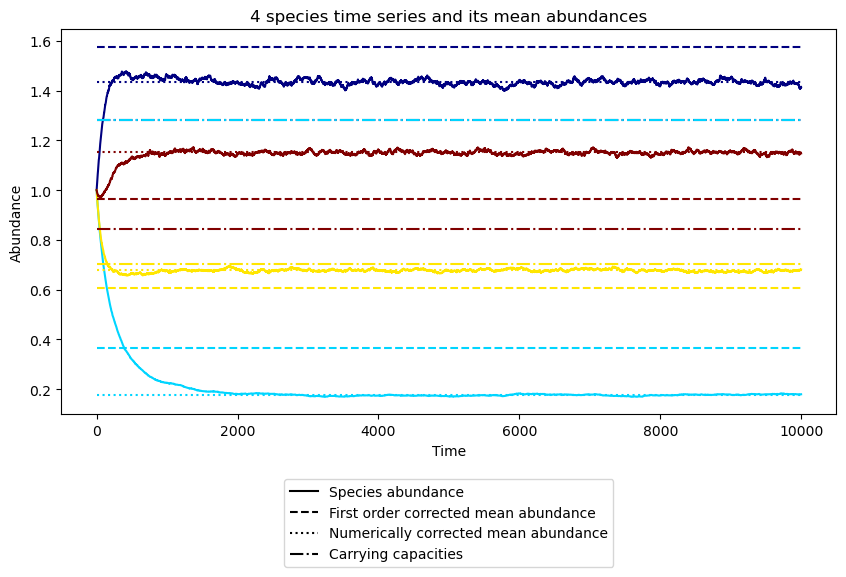

In [3]:
N = 4
dt = 0.01
total_time = 100
steps = int(total_time/dt)
x_0 = np.ones(N)
sigma = 0.01
tau = 1
sigma_ln = 0.5
sigma_n = 0.15
K = np.random.lognormal(sigma=sigma_ln, size=N)

# Creación de la matriz A
N_c = int(N * 0.001/(sigma**2 * K.max()**2))
C = 1
N_c = int(N * N * C)
A = np.zeros((N, N))

flat_indices = np.arange(N*N)
selected_indices = np.random.choice(flat_indices, N_c, False)
rows, columns = np.unravel_index(selected_indices, (N, N))
A[rows, columns] = np.random.normal(scale=sigma_n, size=N_c)

np.fill_diagonal(A, -1 / K)

fo_mean_abundances = K * (2 + A @ K)
numerical_mean_abundances = -np.linalg.inv(A) @ np.ones(N)

t_series = interacting_time_series(x_0, sigma, tau, dt, A, steps)

# plt.hist(t_series[-1], bins=30, density=True, alpha=0.8)

# Colores
cmap = plt.get_cmap('jet')
valores = np.linspace(0, 1, N)
lista_colores = [cmap(v) for v in valores]

for i in range(N):
    plt.hlines(fo_mean_abundances[i], xmin=0, xmax=steps, color=lista_colores[i], linestyles='--')
    plt.hlines(numerical_mean_abundances[i], xmin=0, xmax=steps, color=lista_colores[i], linestyles=':')
    plt.hlines(K[i], xmin=0, xmax=steps, color=lista_colores[i], linestyles='-.')
    plt.plot(t_series[:, i], color=lista_colores[i])
plt.xlabel("Time")
plt.ylabel("Abundance")
solid = plt.Line2D([], [], linestyle='-', label='Species abundance', color='k')
dashed = plt.Line2D([], [],  linestyle='--', label='First order corrected mean abundance', color='k')
dotted = plt.Line2D([], [],  linestyle=':', label='Numerically corrected mean abundance', color='k')
dash_dot = plt.Line2D([], [],  linestyle='-.', label='Carrying capacities', color='k')

plt.gcf().set_size_inches(10, 5)
plt.legend(handles=[solid, dashed, dotted, dash_dot], loc='upper center', bbox_to_anchor=(0.5, -0.15))
plt.title(f"{N} species time series and its mean abundances")
plt.show()




## Jacobian and stablity
### Spectrum of the Jacobian

N_c:  1000000


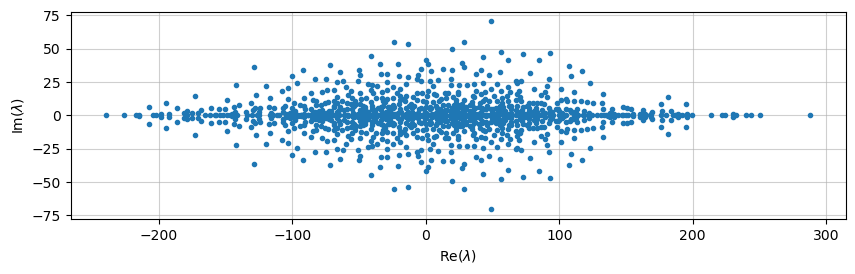

In [138]:
N = 1000

# Generamos la matriz de conexiones según la conectividad C

C = 1
sigma_n = 1
sigma_ln = 1
N_c = int(N * N * C)
print("N_c: ", N_c)
A = np.zeros((N, N))

flat_indices = np.arange(N*N)
selected_indices = np.random.choice(flat_indices, N_c, False)
rows, columns = np.unravel_index(selected_indices, (N, N))
A[rows, columns] = np.random.normal(scale=sigma_n, size=N_c)
K = np.random.lognormal(sigma=sigma_ln, size=N)
np.fill_diagonal(A, -1/K)

# Calculamos el Jacobiano
diagonal = A @ K + np.random.standard_normal(N)
J = A * K[:, None]
np.fill_diagonal(J, diagonal)

# Calculamos los autovalores
eigenvalues = np.linalg.eigvals(J)
plt.plot(eigenvalues.real, eigenvalues.imag, marker='.', linestyle='', rasterized=True)
plt.grid(True, alpha=0.6)
plt.xlabel(r"Re($\lambda$)")
plt.ylabel(r"Im($\lambda$)") 
plt.gca().set_aspect('equal')
plt.gcf().set_figwidth(10)
plt.show()

### Stability and conectivity

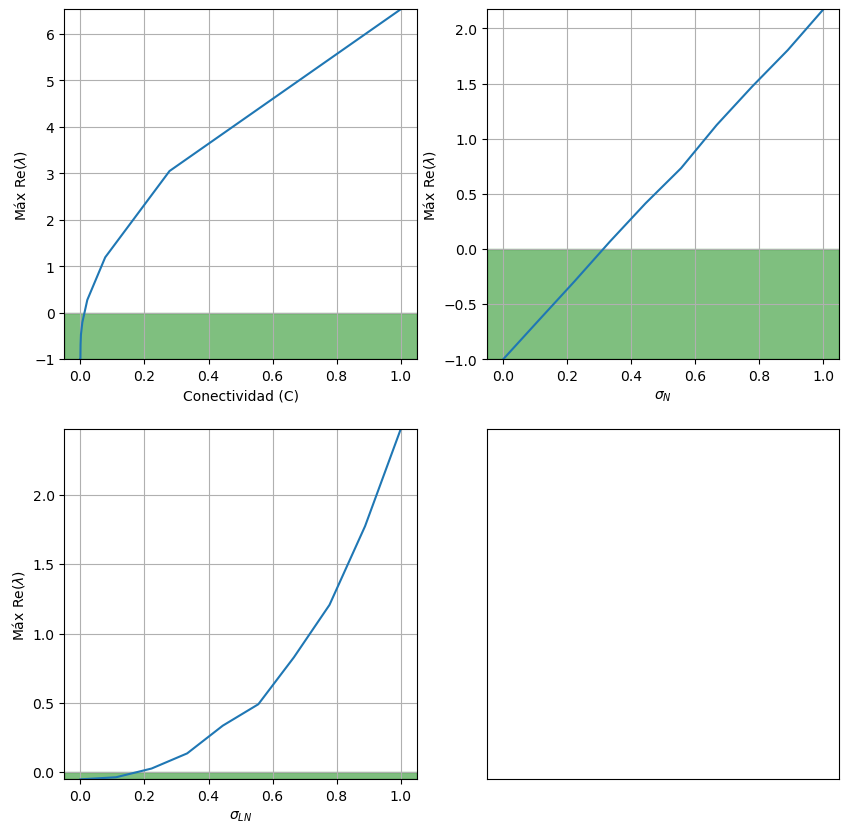

In [111]:
# --- Ejecución ---
N = 100
C_range = np.logspace(-5, 0, 10)
sigma_n_range = np.linspace(0, 1, 10)
sigma_ln_range = np.linspace(0, 1, 10)

single_C = np.array([0.01])
single_sigma_n = np.array([0.3])
single_sigma_ln = np.array([0.03])
n_average = 1000

varying_connections = getMaxRealPart(N, C_range, n_average, single_sigma_n, single_sigma_ln)
varying_sigma_n = getMaxRealPart(N, single_C, n_average, sigma_n_range, single_sigma_ln)
varying_sigma_ln = getMaxRealPart(N, single_C, n_average, single_sigma_n, sigma_ln_range)

# list_max_real_part.shape = (n_connect, n_sn, n_sln)
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 10))

# Plot variando C
ax[0, 0].plot(C_range, varying_connections[:, 0, 0])
ax[0, 0].set_xlabel("Conectividad (C)")
ax[0, 0].set_ylabel(r"Máx Re($\lambda$)")
ymin = varying_connections[:, 0, 0].min()
ymax = varying_connections[:, 0, 0].max()
ax[0, 0].axhspan(ymin=ymin, ymax=0, color='g', alpha=0.5)
ax[0, 0].set_ylim(ymin, ymax)
ax[0, 0].grid(True)

# Plot variando sigma_n
ax[0, 1].plot(sigma_n_range, varying_sigma_n[0, :, 0])
ax[0, 1].set_xlabel(r"$\sigma_N$")
ax[0, 1].set_ylabel(r"Máx Re($\lambda$)")
ymin = varying_sigma_n[0, :, 0].min()
ymax = varying_sigma_n[0, :, 0].max()
ax[0, 1].axhspan(ymin=ymin, ymax=0, color='g', alpha=0.5)
ax[0, 1].set_ylim(ymin, ymax)
ax[0, 1].grid(True)


# Plot variando sigma_ln
ax[1, 0].plot(sigma_ln_range, varying_sigma_ln[0, 0, :])
ax[1, 0].set_xlabel(r"$\sigma_{LN}$")
ax[1, 0].set_ylabel(r"Máx Re($\lambda$)")
ymin = varying_sigma_ln[0, 0, :].min()
ymax = varying_sigma_ln[0, 0, :].max()
ax[1, 0].axhspan(ymin=ymin, ymax=0, color='g', alpha=0.5)
ax[1, 0].set_ylim(ymin, ymax)
ax[1, 0].grid(True)


ax[1,1].set_xticks([])
ax[1,1].set_yticks([])


plt.show()

## 3D stability representation

In [ ]:
# --- Ejecución ---
N = 100
C_range = np.logspace(-5, 0, 10)
sigma_n_range = np.linspace(0, 1, 10)
sigma_ln_range = np.linspace(0, 1, 10)

n_average = 1000

max_eigenvalue_3D = getMaxRealPart(N, C_range, n_average, sigma_n_range, sigma_ln_range)
voxels = max_eigenvalue_3D < 0

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(projection='3d')

# 4. Dibujar los cubos rellenos
# 'facecolors' define el color de los cubos y 'edgecolor' el de las aristas
ax.voxels(voxels, facecolors='royalblue', edgecolor='black', linewidth=0.5)

# Ajustes estéticos opcionales
ax.set_xlabel('C')
ax.set_ylabel(r'$\sigma_{\mathcal{N}}$')
ax.set_zlabel(r'$\sigma_{\mathcal{LN}}$')
ax.set_title('Visualización de Array 3D (Voxels)')


plt.show()

## Correlation and connectivity

In [ ]:
N = 1000
dt = 0.01
total_time = 10000
steps = int(total_time/dt)
init = int(0.2 * steps)
x_0 = np.ones(N)
sigma = 0.01
tau = 1

# Creación de la matriz A seleccionando la conectividad
C = 1
sigma_n = 0.02
sigma_ln = 0.1
K_range = np.random.lognormal(sigma=sigma_ln, size=N)
N_c = int(N * N * C)
print("N_c: ", N_c)
print("K_max: ", K_range.max())
A = np.zeros((N, N))

rng = np.random.default_rng()
selected_indices = rng.choice(N * N, size=N_c, replace=False)
rows, columns = np.unravel_index(selected_indices, (N, N))
A[rows, columns] = np.random.normal(scale=sigma_n, size=N_c)
np.fill_diagonal(A, -1 / K_range)

# Simulación de las series temporales 
t_series = interacting_time_series(x_0, sigma, tau, dt, A, steps)

corr_matrix = np.corrcoef(t_series[init:], rowvar=False)
enlace = sc.cluster.hierarchy.linkage(corr_matrix, method='ward')
indices_ordenados = sc.cluster.hierarchy.dendrogram(enlace, no_plot=True)['leaves']
matriz_reordenada = corr_matrix[indices_ordenados][:, indices_ordenados]

# Dibujado de las figuras
fig, ax = plt.subplots(ncols=2, figsize=(12, 5), layout='constrained')

# Matriz de correlación agrupada
im1 = ax[1].imshow(matriz_reordenada, vmin=-1, vmax=1, cmap='viridis', aspect='equal', interpolation='None')
fig.colorbar(im1, ax=ax[1])

ax[1].set_title(r"Clustered correlation matrix of $x_i$")

# Matriz de correlación sin agrupar
im0 = ax[0].imshow(corr_matrix, vmin=-1, vmax=1, cmap='viridis', aspect='equal', interpolation='None')
fig.colorbar(im0, ax=ax[0])

ax[0].set_title(r"Original correlation matrix of $x_i$")

plt.show()

# Histograma de las correlaciones
mask = ~np.eye(N, dtype=bool)
plt.hist(corr_matrix[mask], bins=500, density=True, alpha=0.8, range=[-1, 1])
plt.title("Correlation coefficients between species")

std_emp = np.std(corr_matrix[mask])
x_range = np.linspace(-1, 1, 1000)
gaussian = sc.stats.norm.pdf(x_range, scale=std_emp)
plt.plot(x_range, gaussian, label="Normal distribution")
plt.legend()
plt.show()

# Autovalores de las matrices de correlación 
rng = np.random.default_rng()
M = rng.standard_normal((N,N))
random_sym = (M + M.T)/2
corr_eigvals = np.sort(np.linalg.eigvalsh(corr_matrix))[::-1]
random_eigvals = np.sort(np.linalg.eigvalsh(random_sym))[::-1]
plt.loglog(corr_eigvals, marker='.', label="Correlation matrix eigenvalues")
plt.loglog(random_eigvals, marker='.', label="Random matrix eigenvalues")
plt.legend()

N_c:  1000000
K_max:  1.3991523729463449


## Phase transitions

In [43]:
%matplotlib inline
N = 100
C = 0.85

tau = 1

dt = 0.01
steps = int(100/dt)

sigma = 2
A , K = construir_matriz_ISLM(N, C, sigma, 0, 1)

X_0 = np.ones(N)
X_0_pert = X_0 + np.random.normal(0, 1, N)

X = deterministic_interacting_time_series(X_0, tau, dt, A, steps)
X_pert = deterministic_interacting_time_series(X_0_pert, tau, dt, A, steps)

plt.close()
fig, ax = plt.subplots(ncols=2, figsize=(10, 5))

# --- PRIMER GRÁFICO ---

ax[0].plot(X)
ax[0].set_title("Series temporales")

# --- SEGUNDO GRÁFICO ---

ax[1].plot(X_pert)
ax[1].set_title("Series temporales")

plt.show()

/home/olmoviviens/miniforge3/envs/fisica/lib/python3.12/site-packages/matplotlib/ticker.py:2178: RuntimeWarning: overflow encountered in multiply
  steps = self._extended_steps * scale
/home/olmoviviens/miniforge3/envs/fisica/lib/python3.12/site-packages/matplotlib/ticker.py:2220: RuntimeWarning: overflow encountered in scalar subtract
  high = edge.ge(_vmax - best_vmin)
/home/olmoviviens/miniforge3/envs/fisica/lib/python3.12/site-packages/matplotlib/ticker.py:2036: RuntimeWarning: invalid value encountered in scalar divmod
  d, m = divmod(x, self.step)


ValueError: arange: cannot compute length

<Figure size 1000x500 with 2 Axes>